In [ ]:
#Importação das dependências

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, VectorIndexer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [ ]:
#Chamando o google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#Chamando nossa base de dados
df = pd.read_csv("/content/drive/MyDrive/ANALISE_PI/alunos_com_erros.csv")

In [ ]:
# Ver os primeiros dados
df.head()

# Verificar tipos e valores nulos
df.info()
df.isnull().sum()


In [ ]:
# Preenchimento ou remoção de valores nulos
df_model = df_model.dropna()

label_encoders = {}
for col in df_model.select_dtypes(include='object').columns:
    if col != 'risco_evasao':
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le

# Separar features (X) e target (y)
X = df_model.drop(columns=['risco_evasao'])
y = df_model['risco_evasao']

# Codificar o target
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
#clusters

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=le_y.classes_.astype(str)))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1693
           1       0.99      0.72      0.83       201

    accuracy                           0.97      1894
   macro avg       0.98      0.86      0.91      1894
weighted avg       0.97      0.97      0.97      1894



Silhouette Score: 0.043519938403802555


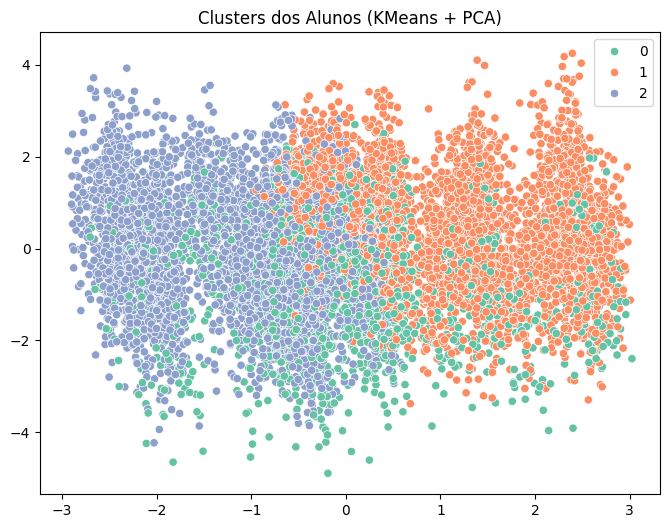

In [ ]:
# 3 clusters (por exemplo, Alto, Médio, Baixo risco)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Silhouette Score
print("Silhouette Score:", silhouette_score(X_scaled, clusters))

# Visualização
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='Set2')
plt.title('Clusters dos Alunos (KMeans + PCA)')
plt.show()


In [ ]:
#MODELO DE REGRESSÃO

# Usando todos os dados menos a variável alvo
X_reg = df_model.drop(columns=['desempenho_1'], errors='ignore')
y_reg = df_model['desempenho_1']

# Divisão de treino e teste
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Regressão linear
reg = LinearRegression()
reg.fit(X_train_r, y_train_r)

# Predição
y_pred_r = reg.predict(X_test_r)

# Avaliação
print("R²:", r2_score(y_test_r, y_pred_r))
print("MSE:", mean_squared_error(y_test_r, y_pred_r))


R²: 0.5322242036767961
MSE: 0.3317674885978487


In [ ]:
#Modelo de PLN (Processamento de Linguagem Natural) ESSA PARTE PRECISA DE UMA COLUNA LIVRE PARA O PLN FUNCIONAR ENTÃO TEMOS QUE CRIAR UMA COLUNA DE OBSERVAÇÕES

# Suponha que você tenha uma coluna chamada 'obs' (observações textuais)
if 'obs' in df.columns:
    df_pln = df.dropna(subset=['obs', 'risco_evasao'])
    X_text = df_pln['obs'].astype(str)
    y_text = LabelEncoder().fit_transform(df_pln['risco_evasao'])

    # Vetorização TF-IDF
    vectorizer = TfidfVectorizer(stop_words='portuguese')
    X_vec = vectorizer.fit_transform(X_text)

    # Classificador Naive Bayes
    X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(X_vec, y_text, test_size=0.2, random_state=42)

    clf_text = MultinomialNB()
    clf_text.fit(X_train_text, y_train_text)

    y_pred_text = clf_text.predict(X_test_text)

    print("Relatório PLN:")
    print(classification_report(y_test_text, y_pred_text))
else:
    print("A coluna 'obs' com texto não foi encontrada.")


A coluna 'obs' com texto não foi encontrada.


In [ ]:
#PARTE DO SPARKY
#criar o spark com sessão
#Nesta parte inicia uma sessão com o spark onde ele cria um 'localhost'
spark = SparkSession.builder.appName("Modelo_Alunos").master("local[*]").getOrCreate()

In [ ]:
df_spark = spark.read.csv("/content/drive/MyDrive/ANALISE_PI/alunos_com_erros.csv", header=True, inferSchema=True)
df_spark.printSchema()
df_spark.show(5)

In [41]:
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import col

# Indexar a coluna alvo
indexer = StringIndexer(inputCol="risco_evasao", outputCol="label")
df_indexed = indexer.fit(df_spark).transform(df_spark)

# Selecionar colunas numéricas
features = ["idade", "renda_familiar", "notas_1", "faltas_1", "desempenho_1"]

# Primeiro, converter as colunas para double (se necessário)
for coluna in features:
    df_indexed = df_indexed.withColumn(coluna, col(coluna).cast("double"))

# Agora, substituir valores nulos pela média
for coluna in features:
    # Calcular a média da coluna, ignorando nulos
    media_coluna = df_indexed.select(col(coluna)).agg({coluna: "mean"}).collect()[0][0]
    # Substituir valores nulos pela média apenas se a média não for nula
    if media_coluna is not None:
        df_indexed = df_indexed.na.fill({coluna: media_coluna})
    else:
        # Se todos os valores forem nulos, preencher com 0 ou outro valor padrão
        df_indexed = df_indexed.na.fill({coluna: 0.0})

# Criar vetor de features
assembler = VectorAssembler(inputCols=features, outputCol="features")
df_final = assembler.transform(df_indexed)

# Separar treino e teste
train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=42)

# Treinar árvore de decisão
dt = DecisionTreeClassifier(labelCol="label", featuresCol="features")
model = dt.fit(train_data)

# Prever
predictions = model.transform(test_data)

# Avaliar
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print("Acurácia do modelo:", accuracy)

print("Colunas disponíveis:", df_spark.columns)
print("Contagem de linhas:", df_spark.count())
for coluna in features:
    print(f"Tipo da coluna {coluna}:", df_spark.schema[coluna].dataType)

Acurácia do modelo: 0.905257678292556
Colunas disponíveis: ['aluno_id', 'nome_aluno', 'email_aluno', 'curso', 'status', 'turma', 'sexo', 'idade', 'trabalha', 'renda_familiar', 'acompanhamento_medico', 'tem_filho', 'estado_civil', 'semestre', 'bimestre', 'aula_1', 'professor_1', 'notas_1', 'faltas_1', 'desempenho_1', 'aula_2', 'professor_2', 'notas_2', 'faltas_2', 'desempenho_2', 'aula_3', 'professor_3', 'notas_3', 'faltas_3', 'desempenho_3', 'aula_4', 'professor_4', 'notas_4', 'faltas_4', 'desempenho_4', 'aula_5', 'professor_5', 'notas_5', 'faltas_5', 'desempenho_5', 'risco_evasao']
Contagem de linhas: 10000
Tipo da coluna idade: DoubleType()
Tipo da coluna renda_familiar: LongType()
Tipo da coluna notas_1: DoubleType()
Tipo da coluna faltas_1: IntegerType()
Tipo da coluna desempenho_1: StringType()
